In [1]:
# ==============================
# STEP 1 : IMPORT LIBRARIES
# ==============================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Date Handling
from datetime import datetime

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Set Visualization Style
sns.set_style("darkgrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ==============================
# STEP 2 : LOAD DATASETS
# ==============================

# Load Dataset 1
df1 = pd.read_csv("ebola_2014_2016_clean.csv")

# Load Dataset 2
df2 = pd.read_csv("ebola_data_db_format.csv")

# Display first 5 rows
print("DATASET 1")
display(df1.head())

print("\nDATASET 2")
display(df2.head())

DATASET 1


,Country,Date,"Cumulative no. of confirmed, probable and suspected cases","Cumulative no. of confirmed, probable and suspected deaths"
0,Guinea,2014-08-29,648.0,430.0
1,Nigeria,2014-08-29,19.0,7.0
2,Sierra Leone,2014-08-29,1026.0,422.0
3,Liberia,2014-08-29,1378.0,694.0
4,Sierra Leone,2014-09-05,1261.0,491.0



DATASET 2


,Indicator,Country,Date,value
0,"Cumulative number of confirmed, probable and s...",Guinea,2015-03-10,3285.0
1,Cumulative number of confirmed Ebola cases,Guinea,2015-03-10,2871.0
2,Cumulative number of probable Ebola cases,Guinea,2015-03-10,392.0
3,Cumulative number of suspected Ebola cases,Guinea,2015-03-10,22.0
4,"Cumulative number of confirmed, probable and s...",Guinea,2015-03-10,2170.0


In [3]:
# ==============================
# CHECK DATASET INFORMATION
# ==============================

print("DATASET 1 INFO")
print(df1.info())

print("\n=========================\n")

print("DATASET 2 INFO")
print(df2.info())

DATASET 1 INFO
<class 'pandas.DataFrame'>
RangeIndex: 2485 entries, 0 to 2484
Data columns (total 4 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Country                                                     2485 non-null   str    
 1   Date                                                        2485 non-null   str    
 2   Cumulative no. of confirmed, probable and suspected cases   2477 non-null   float64
 3   Cumulative no. of confirmed, probable and suspected deaths  2485 non-null   float64
dtypes: float64(2), str(2)
memory usage: 77.8 KB
None


DATASET 2 INFO
<class 'pandas.DataFrame'>
RangeIndex: 17585 entries, 0 to 17584
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Indicator  17585 non-null  str    
 1   Country    17585 non-null  str    
 2   Date       17585 non-nu

In [4]:
# ==============================
# CHECK MISSING VALUES
# ==============================

print("Missing Values in Dataset 1")
print(df1.isnull().sum())

print("\n=========================\n")

print("Missing Values in Dataset 2")
print(df2.isnull().sum())

Missing Values in Dataset 1
Country                                                       0
Date                                                          0
Cumulative no. of confirmed, probable and suspected cases     8
Cumulative no. of confirmed, probable and suspected deaths    0
dtype: int64


Missing Values in Dataset 2
Indicator    0
Country      0
Date         0
value        0
dtype: int64


In [5]:
# ==============================
# CONVERT DATE COLUMNS
# ==============================

# Convert date column to datetime
df1['Date'] = pd.to_datetime(df1['Date'])

df2['Date'] = pd.to_datetime(df2['Date'])

print("Date Columns Converted Successfully!")

Date Columns Converted Successfully!


In [6]:
# ==============================
# FINAL DATASET CHECK
# ==============================

print(df1.head())

print("\n=========================\n")

print(df2.head())

        Country       Date  \
0        Guinea 2014-08-29   
1       Nigeria 2014-08-29   
2  Sierra Leone 2014-08-29   
3       Liberia 2014-08-29   
4  Sierra Leone 2014-09-05   

   Cumulative no. of confirmed, probable and suspected cases  \
0                                              648.0           
1                                               19.0           
2                                             1026.0           
3                                             1378.0           
4                                             1261.0           

   Cumulative no. of confirmed, probable and suspected deaths  
0                                              430.0           
1                                                7.0           
2                                              422.0           
3                                              694.0           
4                                              491.0           


                                           Indic

In [7]:
# ==============================
# STEP 3.1 : RENAME COLUMNS
# ==============================

# Rename columns in Dataset 1
df1 = df1.rename(columns={
    'Cumulative no. of confirmed, probable and suspected cases': 'Cases',
    'Cumulative no. of confirmed, probable and suspected deaths': 'Deaths'
})

# Rename columns in Dataset 2
df2 = df2.rename(columns={
    'value': 'Value'
})

print("Columns Renamed Successfully!")

Columns Renamed Successfully!


In [8]:
# ==============================
# CHECK NEW COLUMN NAMES
# ==============================

print(df1.columns)
print("\n====================\n")
print(df2.columns)

Index(['Country', 'Date', 'Cases', 'Deaths'], dtype='str')


Index(['Indicator', 'Country', 'Date', 'Value'], dtype='str')


In [9]:
# ==============================
# HANDLE MISSING VALUES
# ==============================

# Check missing values
print(df1.isnull().sum())

# Fill missing values with 0
df1['Cases'] = df1['Cases'].fillna(0)
df1['Deaths'] = df1['Deaths'].fillna(0)

print("\nMissing Values Handled Successfully!")

Country    0
Date       0
Cases      8
Deaths     0
dtype: int64

Missing Values Handled Successfully!


In [10]:
# ==============================
# CONVERT DATA TYPES
# ==============================

# Convert to integer
df1['Cases'] = df1['Cases'].astype(int)
df1['Deaths'] = df1['Deaths'].astype(int)

print(df1.dtypes)

Country               str
Date       datetime64[us]
Cases               int64
Deaths              int64
dtype: object


In [11]:
# ==============================
# SORT DATA BY DATE
# ==============================

df1 = df1.sort_values(by='Date')

print("Data Sorted Successfully!")

Data Sorted Successfully!


In [12]:
# ==============================
# RESET INDEX
# ==============================

df1 = df1.reset_index(drop=True)

print(df1.head())

        Country       Date  Cases  Deaths
0        Guinea 2014-08-29    648     430
1       Nigeria 2014-08-29     19       7
2  Sierra Leone 2014-08-29   1026     422
3       Liberia 2014-08-29   1378     694
4  Sierra Leone 2014-09-05   1261     491


In [13]:
# ==============================
# FINAL CLEAN DATASET
# ==============================

print(df1.info())

print("\n=========================\n")

display(df1.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 2485 entries, 0 to 2484
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Country  2485 non-null   str           
 1   Date     2485 non-null   datetime64[us]
 2   Cases    2485 non-null   int64         
 3   Deaths   2485 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 77.8 KB
None




,Country,Date,Cases,Deaths
0,Guinea,2014-08-29,648,430
1,Nigeria,2014-08-29,19,7
2,Sierra Leone,2014-08-29,1026,422
3,Liberia,2014-08-29,1378,694
4,Sierra Leone,2014-09-05,1261,491
5,Nigeria,2014-09-05,22,8
6,Liberia,2014-09-05,1871,1089
7,Guinea,2014-09-05,812,517
8,Senegal,2014-09-05,1,0
9,Senegal,2014-09-08,3,0


In [14]:
# ==============================
# STEP 4.1 : DATASET OVERVIEW
# ==============================

print("Shape of Dataset :", df1.shape)

print("\nColumns:")
print(df1.columns)

print("\nStatistical Summary:")
display(df1.describe())

Shape of Dataset : (2485, 4)

Columns:
Index(['Country', 'Date', 'Cases', 'Deaths'], dtype='str')

Statistical Summary:


,Date,Cases,Deaths
count,2485,2485.000000,2485.000000
mean,2015-06-07 23:18:51.428571,2545.457545,1028.347686
min,2014-08-29 00:00:00,0.000000,0.000000
25%,2015-03-05 00:00:00,1.000000,0.000000
50%,2015-06-22 00:00:00,8.000000,6.000000
75%,2015-09-09 00:00:00,3652.000000,2386.000000
max,2016-03-23 00:00:00,14122.000000,4806.000000
std,NaN,4422.350958,1656.064372


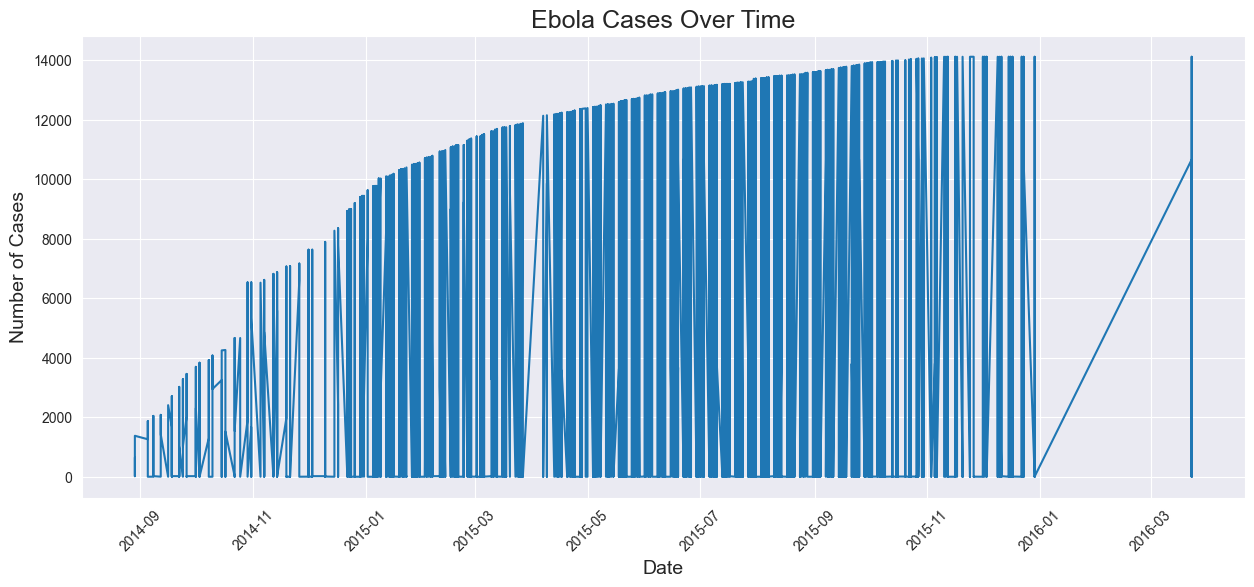

In [15]:
# ==============================
# TOTAL CASES OVER TIME
# ==============================

plt.figure(figsize=(15,6))

plt.plot(df1['Date'], df1['Cases'])

plt.title("Ebola Cases Over Time", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of Cases", fontsize=14)

plt.xticks(rotation=45)

plt.show()

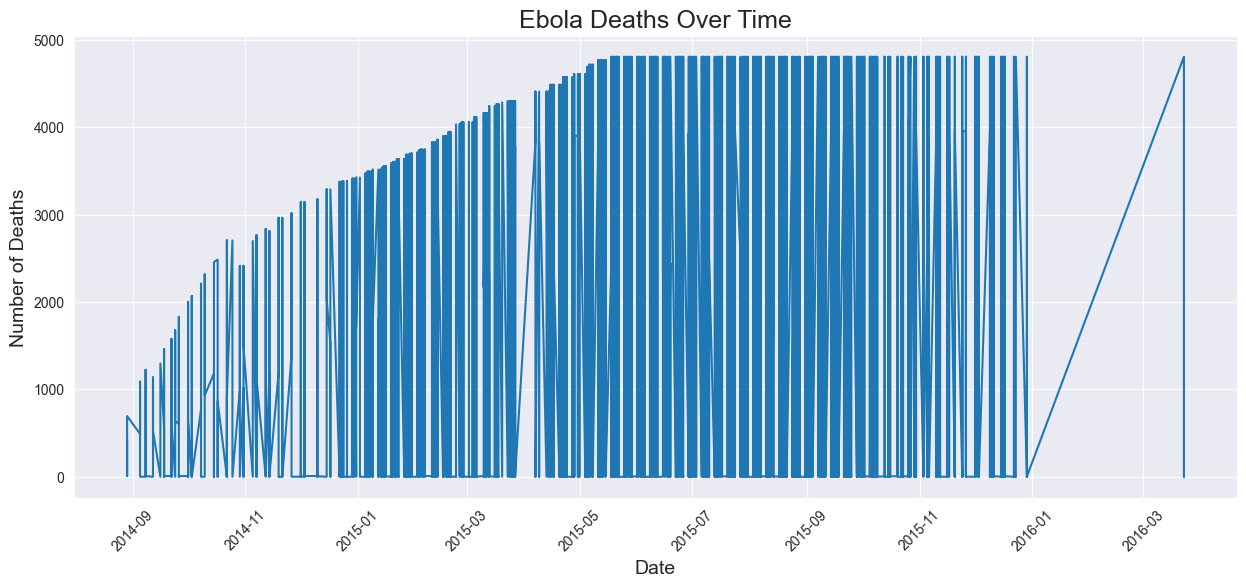

In [16]:
# ==============================
# TOTAL DEATHS OVER TIME
# ==============================

plt.figure(figsize=(15,6))

plt.plot(df1['Date'], df1['Deaths'])

plt.title("Ebola Deaths Over Time", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of Deaths", fontsize=14)

plt.xticks(rotation=45)

plt.show()

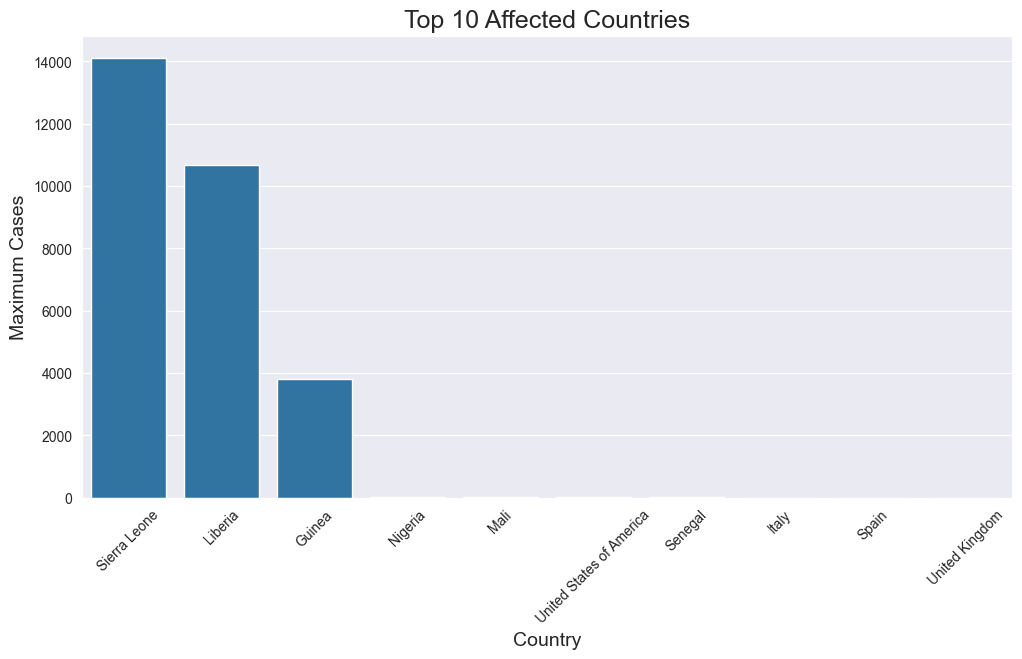

In [17]:
# ==============================
# TOP AFFECTED COUNTRIES
# ==============================

top_countries = (
    df1.groupby('Country')['Cases']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title("Top 10 Affected Countries", fontsize=18)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Maximum Cases", fontsize=14)

plt.xticks(rotation=45)

plt.show()

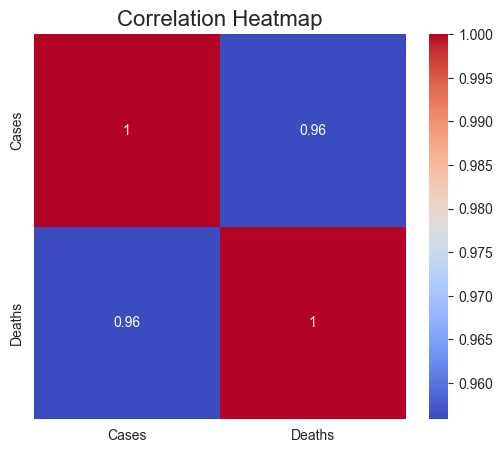

In [18]:
# ==============================
# CORRELATION HEATMAP
# ==============================

# Select numerical columns
numeric_df = df1[['Cases', 'Deaths']]

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

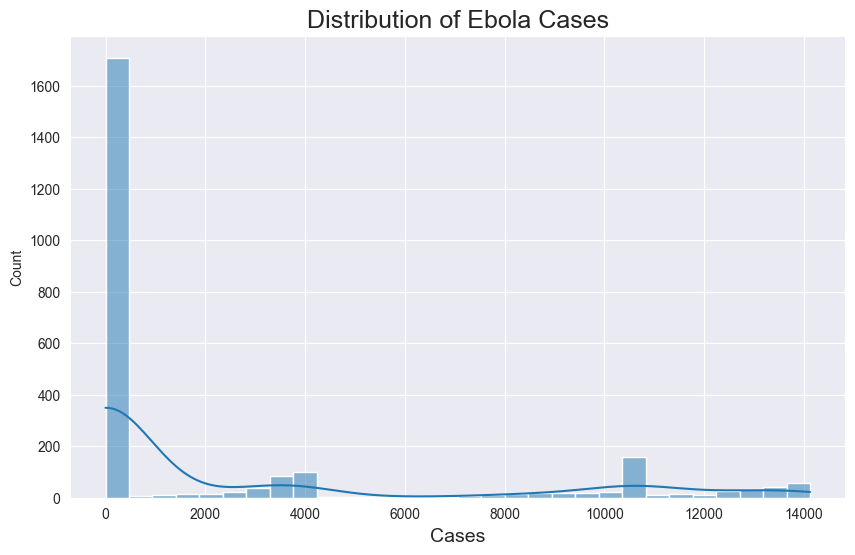

In [19]:
# ==============================
# DISTRIBUTION OF CASES
# ==============================

plt.figure(figsize=(10,6))

sns.histplot(df1['Cases'], bins=30, kde=True)

plt.title("Distribution of Ebola Cases", fontsize=18)
plt.xlabel("Cases", fontsize=14)

plt.show()

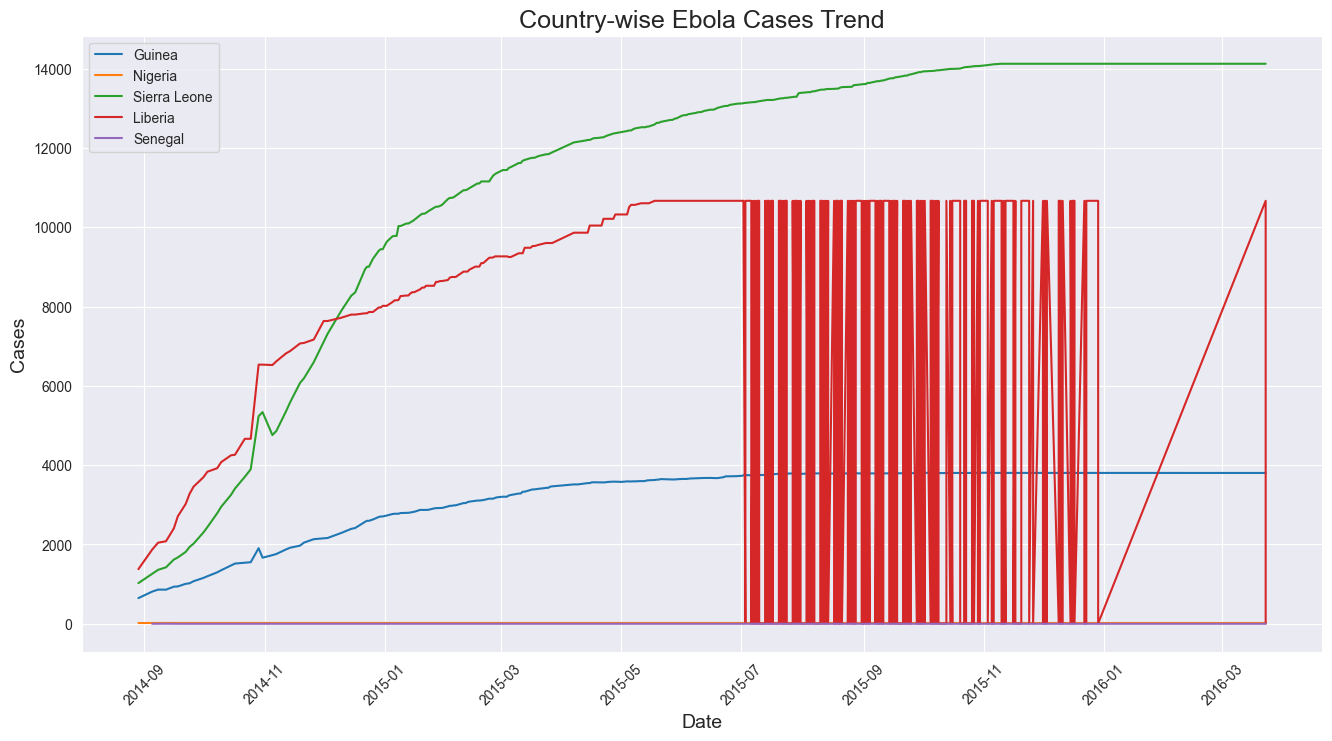

In [20]:
# ==============================
# COUNTRY-WISE CASE TREND
# ==============================

plt.figure(figsize=(16,8))

countries = df1['Country'].unique()

for country in countries[:5]:
    
    country_data = df1[df1['Country'] == country]
    
    plt.plot(
        country_data['Date'],
        country_data['Cases'],
        label=country
    )

plt.title("Country-wise Ebola Cases Trend", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Cases", fontsize=14)

plt.legend()

plt.xticks(rotation=45)

plt.show()

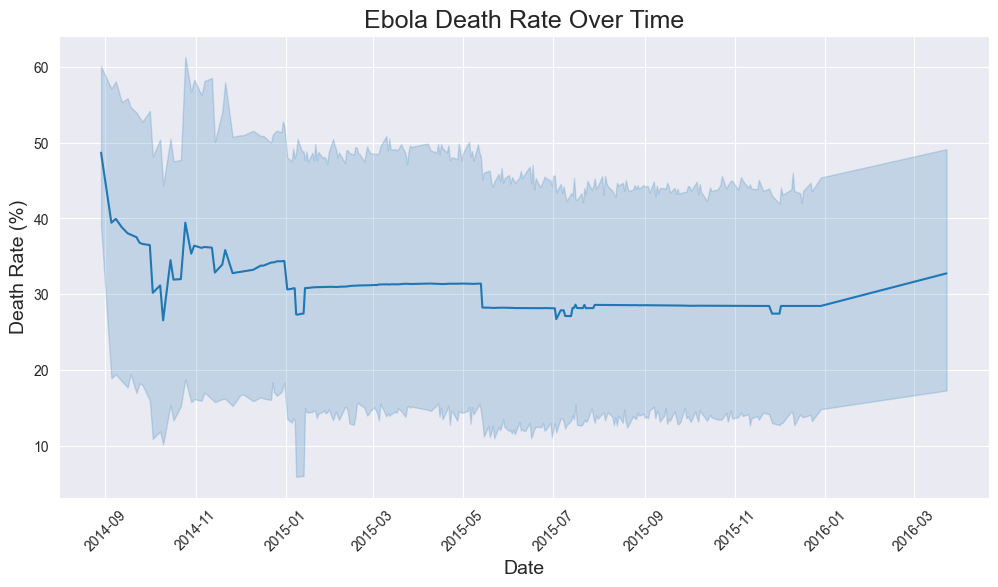

In [21]:
# ==============================
# DEATH RATE ANALYSIS
# ==============================

# Avoid division by zero
df1['Death_Rate'] = np.where(
    df1['Cases'] > 0,
    (df1['Deaths'] / df1['Cases']) * 100,
    0
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=df1['Date'],
    y=df1['Death_Rate']
)

plt.title("Ebola Death Rate Over Time", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Death Rate (%)", fontsize=14)

plt.xticks(rotation=45)

plt.show()

In [22]:
# ==============================
# STEP 5.1 : CONVERT DATE TO NUMERIC
# ==============================

# Convert date into ordinal number
df1['Date_Ordinal'] = df1['Date'].map(datetime.toordinal)

print(df1[['Date', 'Date_Ordinal']].head())

        Date  Date_Ordinal
0 2014-08-29        735474
1 2014-08-29        735474
2 2014-08-29        735474
3 2014-08-29        735474
4 2014-09-05        735481


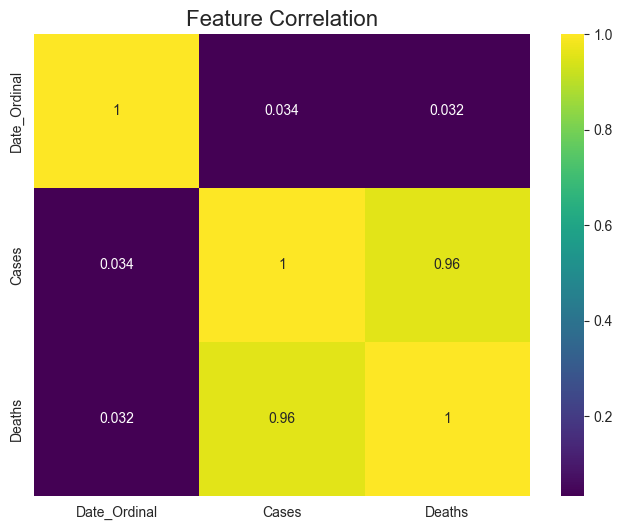

In [23]:
# ==============================
# CHECK CORRELATION
# ==============================

corr_data = df1[['Date_Ordinal', 'Cases', 'Deaths']]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='viridis'
)

plt.title("Feature Correlation", fontsize=16)

plt.show()

In [24]:
# ==============================
# DEFINE FEATURES & TARGETS
# ==============================

# Feature
X = df1[['Date_Ordinal']]

# Targets
y_cases = df1['Cases']
y_deaths = df1['Deaths']

print("Features and Targets Created Successfully!")

Features and Targets Created Successfully!


In [25]:
# ==============================
# TRAIN TEST SPLIT FOR CASES
# ==============================

X_train_cases, X_test_cases, y_train_cases, y_test_cases = train_test_split(
    X,
    y_cases,
    test_size=0.2,
    random_state=42
)

print("Cases Data Split Successfully!")

Cases Data Split Successfully!


In [26]:
# ==============================
# TRAIN TEST SPLIT FOR DEATHS
# ==============================

X_train_deaths, X_test_deaths, y_train_deaths, y_test_deaths = train_test_split(
    X,
    y_deaths,
    test_size=0.2,
    random_state=42
)

print("Deaths Data Split Successfully!")

Deaths Data Split Successfully!


In [27]:
# ==============================
# CHECK TRAIN TEST SHAPES
# ==============================

print("X_train_cases shape :", X_train_cases.shape)
print("X_test_cases shape :", X_test_cases.shape)

print("\n=========================\n")

print("y_train_cases shape :", y_train_cases.shape)
print("y_test_cases shape :", y_test_cases.shape)

X_train_cases shape : (1988, 1)
X_test_cases shape : (497, 1)


y_train_cases shape : (1988,)
y_test_cases shape : (497,)


In [28]:
# ==============================
# LINEAR REGRESSION - CASES
# ==============================

# Create model
lr_cases = LinearRegression()

# Train model
lr_cases.fit(X_train_cases, y_train_cases)

print("Linear Regression Model for Cases Trained Successfully!")

Linear Regression Model for Cases Trained Successfully!


In [29]:
# ==============================
# PREDICT CASES
# ==============================

# Predictions
lr_cases_predictions = lr_cases.predict(X_test_cases)

# Display predictions
print(lr_cases_predictions[:10])

[2538.47249106 2495.06808821 2640.47283778 2330.13135734 2488.55742778
 2416.94016306 2500.49363856 2623.11107664 2588.38755435 2224.87568041]


In [30]:
# ==============================
# EVALUATE LINEAR REGRESSION
# ==============================

# MAE
mae = mean_absolute_error(y_test_cases, lr_cases_predictions)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_cases, lr_cases_predictions))

# R2 Score
r2 = r2_score(y_test_cases, lr_cases_predictions)

print("LINEAR REGRESSION RESULTS")
print("----------------------------")

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

LINEAR REGRESSION RESULTS
----------------------------
MAE : 3675.3402235369344
RMSE : 4673.845021765202
R2 Score : -0.004579619485768793


In [31]:
# ==============================
# RANDOM FOREST - CASES
# ==============================

# Create model
rf_cases = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_cases.fit(X_train_cases, y_train_cases)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [32]:
# ==============================
# RANDOM FOREST PREDICTIONS
# ==============================

rf_predictions = rf_cases.predict(X_test_cases)

print(rf_predictions[:10])

[2891.15129257  868.62744589 2208.97974711 2301.35824603 4777.23914286
 2606.78969228 2092.98541103 2917.02982899 2923.75804978 1578.28210895]


In [33]:
# ==============================
# RANDOM FOREST EVALUATION
# ==============================

# MAE
rf_mae = mean_absolute_error(y_test_cases, rf_predictions)

# RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test_cases, rf_predictions))

# R2 Score
rf_r2 = r2_score(y_test_cases, rf_predictions)

print("RANDOM FOREST RESULTS")
print("----------------------------")

print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

RANDOM FOREST RESULTS
----------------------------
MAE : 4078.5400267365667
RMSE : 5223.1110946164645
R2 Score : -0.2545681977347385


In [34]:
# ==============================
# MODEL COMPARISON
# ==============================

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

display(comparison)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3675.340224,4673.845022,-0.004580
1,Random Forest,4078.540027,5223.111095,-0.254568


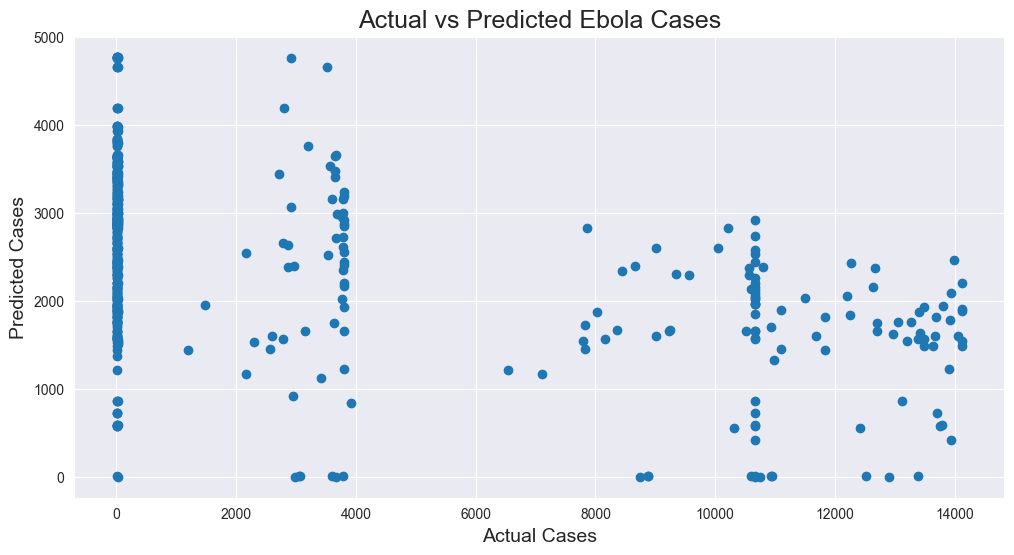

In [35]:
# ==============================
# ACTUAL VS PREDICTED
# ==============================

plt.figure(figsize=(12,6))

plt.scatter(
    y_test_cases,
    rf_predictions
)

plt.xlabel("Actual Cases", fontsize=14)
plt.ylabel("Predicted Cases", fontsize=14)

plt.title("Actual vs Predicted Ebola Cases", fontsize=18)

plt.show()

In [36]:
# ==============================
# TRAIN MODEL FOR DEATHS
# ==============================

# Linear Regression for Deaths
lr_deaths = LinearRegression()

# Train model
lr_deaths.fit(X_train_deaths, y_train_deaths)

print("Death Prediction Model Trained Successfully!")

Death Prediction Model Trained Successfully!


In [37]:
# ==============================
# CREATE FUTURE DATES
# ==============================

# Get latest date in dataset
last_date = df1['Date'].max()

print("Last Date in Dataset :", last_date)

Last Date in Dataset : 2016-03-23 00:00:00


In [38]:
# ==============================
# GENERATE FUTURE DATES
# ==============================

future_dates = pd.date_range(
    start=last_date,
    periods=30
)

future_df = pd.DataFrame({
    'Date': future_dates
})

future_df['Date_Ordinal'] = future_df['Date'].map(datetime.toordinal)

display(future_df.head())

,Date,Date_Ordinal
0,2016-03-23,736046
1,2016-03-24,736047
2,2016-03-25,736048
3,2016-03-26,736049
4,2016-03-27,736050


In [39]:
# ==============================
# PREDICT FUTURE CASES
# ==============================

future_cases = rf_cases.predict(
    future_df[['Date_Ordinal']]
)

future_df['Predicted_Cases'] = future_cases

display(future_df.head())

,Date,Date_Ordinal,Predicted_Cases
0,2016-03-23,736046,2789.071023
1,2016-03-24,736047,2789.071023
2,2016-03-25,736048,2789.071023
3,2016-03-26,736049,2789.071023
4,2016-03-27,736050,2789.071023


In [40]:
# ==============================
# PREDICT FUTURE DEATHS
# ==============================

future_deaths = lr_deaths.predict(
    future_df[['Date_Ordinal']]
)

future_df['Predicted_Deaths'] = future_deaths

display(future_df.head())

,Date,Date_Ordinal,Predicted_Cases,Predicted_Deaths
0,2016-03-23,736046,2789.071023,1125.789572
1,2016-03-24,736047,2789.071023,1126.214975
2,2016-03-25,736048,2789.071023,1126.640378
3,2016-03-26,736049,2789.071023,1127.065781
4,2016-03-27,736050,2789.071023,1127.491184


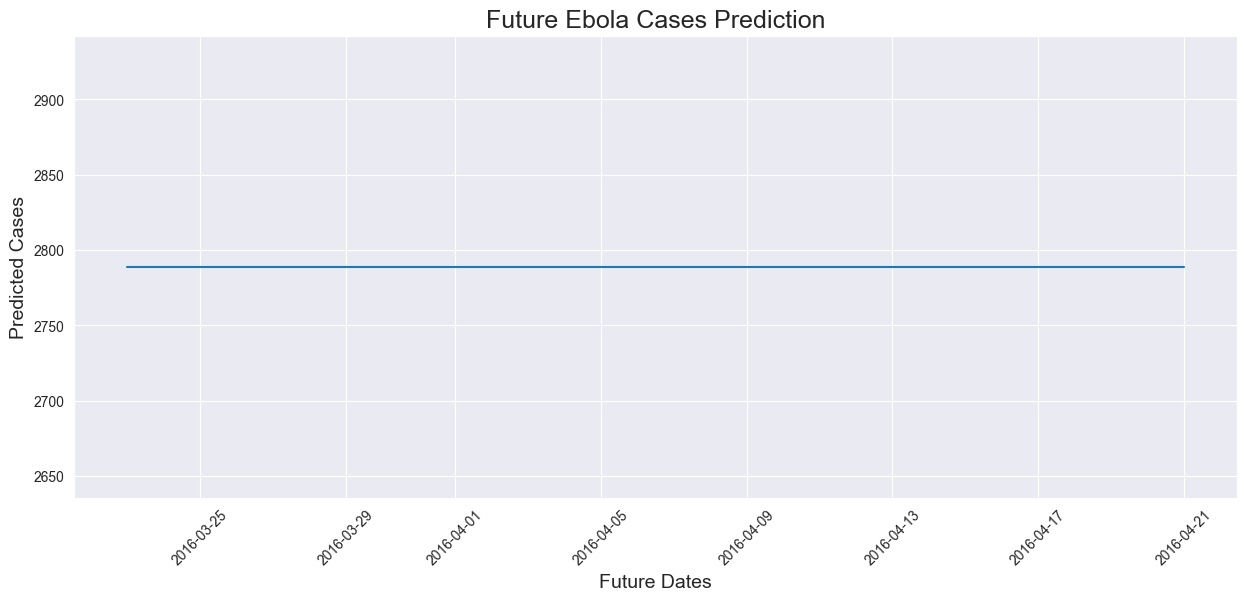

In [41]:
# ==============================
# FUTURE CASES FORECAST
# ==============================

plt.figure(figsize=(15,6))

plt.plot(
    future_df['Date'],
    future_df['Predicted_Cases']
)

plt.title("Future Ebola Cases Prediction", fontsize=18)
plt.xlabel("Future Dates", fontsize=14)
plt.ylabel("Predicted Cases", fontsize=14)

plt.xticks(rotation=45)

plt.show()

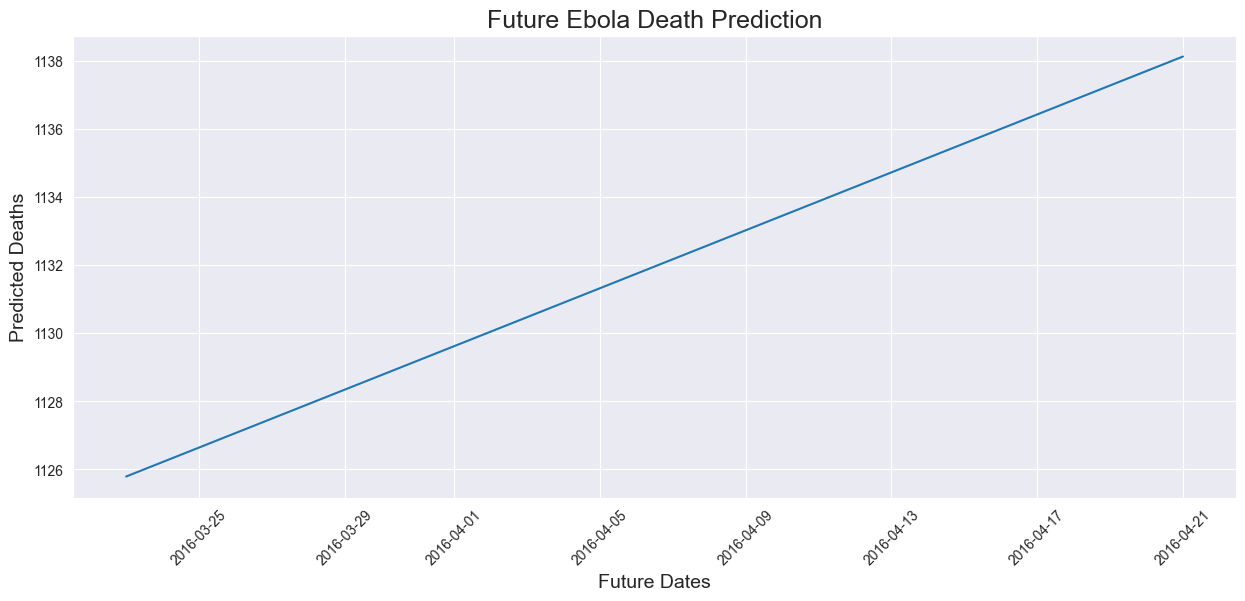

In [42]:
# ==============================
# FUTURE DEATHS FORECAST
# ==============================

plt.figure(figsize=(15,6))

plt.plot(
    future_df['Date'],
    future_df['Predicted_Deaths']
)

plt.title("Future Ebola Death Prediction", fontsize=18)
plt.xlabel("Future Dates", fontsize=14)
plt.ylabel("Predicted Deaths", fontsize=14)

plt.xticks(rotation=45)

plt.show()

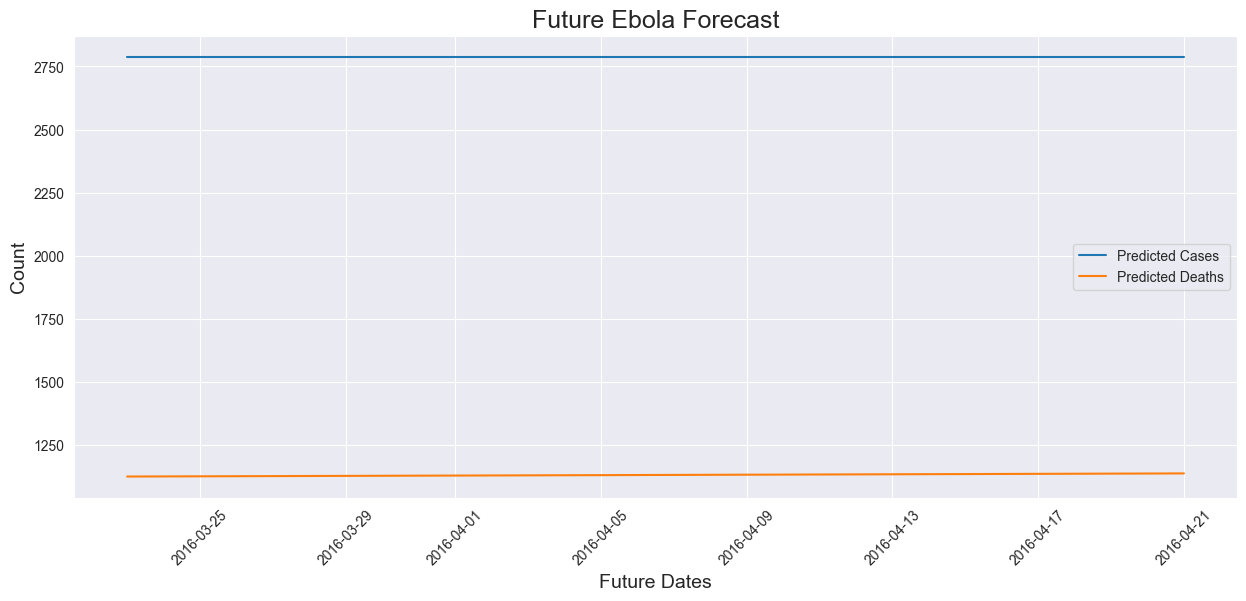

In [43]:
# ==============================
# COMBINED FORECAST GRAPH
# ==============================

plt.figure(figsize=(15,6))

plt.plot(
    future_df['Date'],
    future_df['Predicted_Cases'],
    label='Predicted Cases'
)

plt.plot(
    future_df['Date'],
    future_df['Predicted_Deaths'],
    label='Predicted Deaths'
)

plt.title("Future Ebola Forecast", fontsize=18)
plt.xlabel("Future Dates", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [44]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\MOHD ASAD ALI\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [45]:
# ==============================
# IMPORT PLOTLY
# ==============================

import plotly.express as px

print("Plotly Imported Successfully!")

Plotly Imported Successfully!


In [46]:
# ==============================
# COUNTRY-WISE DATA
# ==============================

country_cases = (
    df1.groupby('Country')['Cases']
    .max()
    .reset_index()
)

display(country_cases.head())

,Country,Cases
0,Guinea,3810
1,Italy,1
2,Liberia,10666
3,Mali,8
4,Nigeria,22


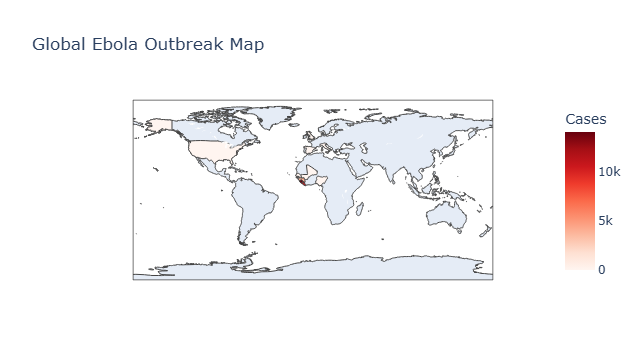

In [47]:
# ==============================
# WORLD MAP VISUALIZATION
# ==============================

fig = px.choropleth(
    country_cases,
    
    locations='Country',
    locationmode='country names',
    
    color='Cases',
    
    hover_name='Country',
    
    color_continuous_scale='Reds',
    
    title='Global Ebola Outbreak Map'
)

fig.show()

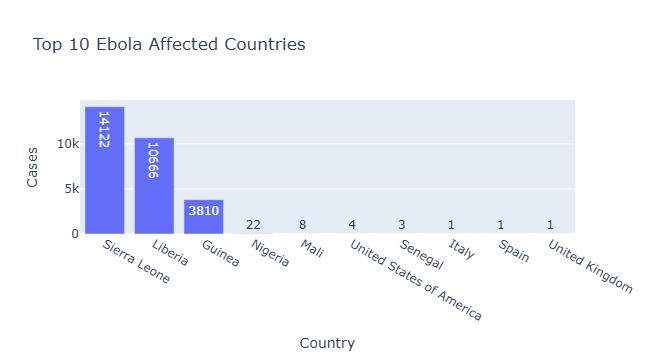

In [48]:
# ==============================
# TOP AFFECTED COUNTRIES MAP
# ==============================

top_country_cases = (
    country_cases
    .sort_values(by='Cases', ascending=False)
    .head(10)
)

fig = px.bar(
    top_country_cases,
    
    x='Country',
    y='Cases',
    
    title='Top 10 Ebola Affected Countries',
    
    text='Cases'
)

fig.show()

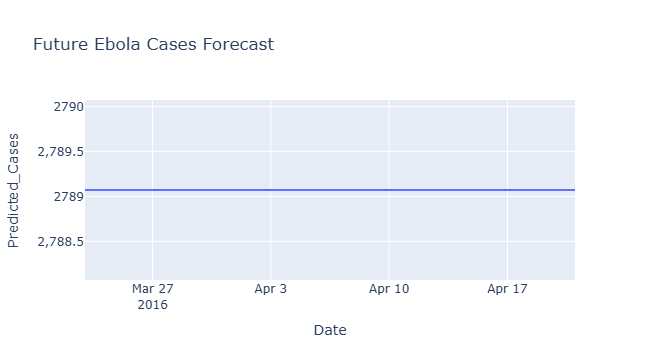

In [49]:
# ==============================
# INTERACTIVE FORECAST GRAPH
# ==============================

fig = px.line(
    future_df,
    
    x='Date',
    y='Predicted_Cases',
    
    title='Future Ebola Cases Forecast'
)

fig.show()

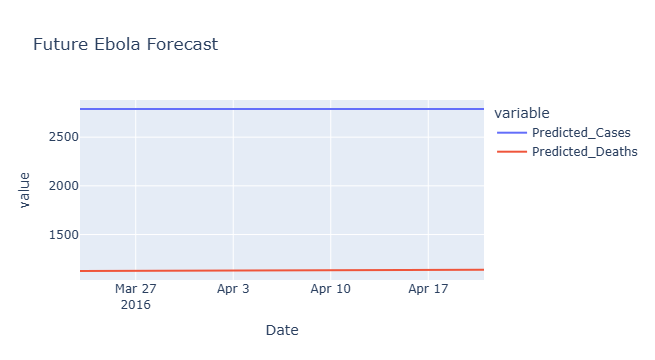

In [50]:
# ==============================
# COMBINED INTERACTIVE FORECAST
# ==============================

fig = px.line(
    future_df,
    
    x='Date',
    
    y=[
        'Predicted_Cases',
        'Predicted_Deaths'
    ],
    
    title='Future Ebola Forecast'
)

fig.show()

In [51]:
# ==============================
# DAILY GROWTH RATE
# ==============================

# Calculate growth rate
df1['Growth_Rate'] = df1['Cases'].pct_change() * 100

# Replace infinite values
df1['Growth_Rate'].replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# Fill missing values
df1['Growth_Rate'].fillna(0, inplace=True)

display(df1.head())


,Country,Date,Cases,Deaths,Death_Rate,Date_Ordinal,Growth_Rate
0,Guinea,2014-08-29,648,430,66.358025,735474,NaN
1,Nigeria,2014-08-29,19,7,36.842105,735474,-97.067901
2,Sierra Leone,2014-08-29,1026,422,41.130604,735474,5300.000000
3,Liberia,2014-08-29,1378,694,50.362845,735474,34.307992
4,Sierra Leone,2014-09-05,1261,491,38.937351,735481,-8.490566


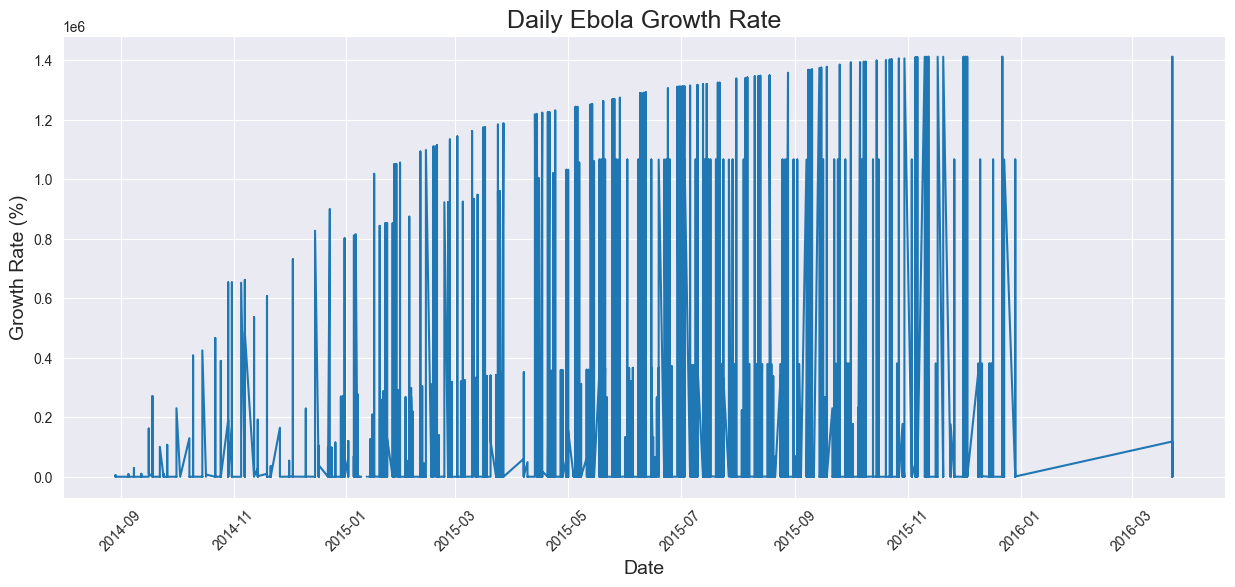

In [52]:
# ==============================
# GROWTH RATE VISUALIZATION
# ==============================

plt.figure(figsize=(15,6))

plt.plot(
    df1['Date'],
    df1['Growth_Rate']
)

plt.title("Daily Ebola Growth Rate", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Growth Rate (%)", fontsize=14)

plt.xticks(rotation=45)

plt.show()

In [53]:
# ==============================
# MOVING AVERAGE
# ==============================

# 7-day moving average
df1['7Day_MA'] = df1['Cases'].rolling(window=7).mean()

display(df1.head(10))

,Country,Date,Cases,Deaths,Death_Rate,Date_Ordinal,Growth_Rate,7Day_MA
0,Guinea,2014-08-29,648,430,66.358025,735474,NaN,NaN
1,Nigeria,2014-08-29,19,7,36.842105,735474,-97.067901,NaN
2,Sierra Leone,2014-08-29,1026,422,41.130604,735474,5300.000000,NaN
3,Liberia,2014-08-29,1378,694,50.362845,735474,34.307992,NaN
4,Sierra Leone,2014-09-05,1261,491,38.937351,735481,-8.490566,NaN
5,Nigeria,2014-09-05,22,8,36.363636,735481,-98.255353,NaN
6,Liberia,2014-09-05,1871,1089,58.204169,735481,8404.545455,889.285714
7,Guinea,2014-09-05,812,517,63.669951,735481,-56.600748,912.714286
8,Senegal,2014-09-05,1,0,0.000000,735481,-99.876847,910.142857
9,Senegal,2014-09-08,3,0,0.000000,735484,200.000000,764.000000


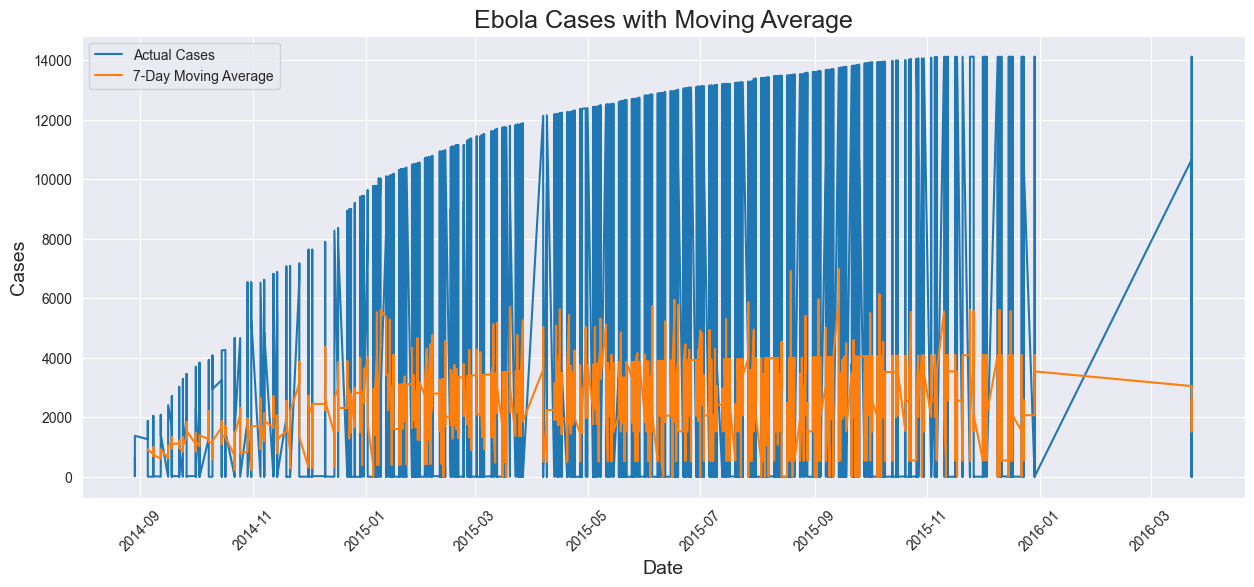

In [54]:
# ==============================
# MOVING AVERAGE GRAPH
# ==============================

plt.figure(figsize=(15,6))

plt.plot(
    df1['Date'],
    df1['Cases'],
    label='Actual Cases'
)

plt.plot(
    df1['Date'],
    df1['7Day_MA'],
    label='7-Day Moving Average'
)

plt.title("Ebola Cases with Moving Average", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Cases", fontsize=14)

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [55]:
# ==============================
# MORTALITY RATE BY COUNTRY
# ==============================

country_stats = (
    df1.groupby('Country')[['Cases', 'Deaths']]
    .max()
)

country_stats['Mortality_Rate'] = (
    country_stats['Deaths'] /
    country_stats['Cases']
) * 100

country_stats = country_stats.sort_values(
    by='Mortality_Rate',
    ascending=False
)

display(country_stats.head(10))

,Cases,Deaths,Mortality_Rate
Country,,,
Mali,8,6,75.000000
Guinea,3810,2536,66.561680
Liberia,10666,4806,45.059066
Nigeria,22,8,36.363636
Sierra Leone,14122,3955,28.005948
United States of America,4,1,25.000000
Italy,1,0,0.000000
Senegal,3,0,0.000000
Spain,1,0,0.000000


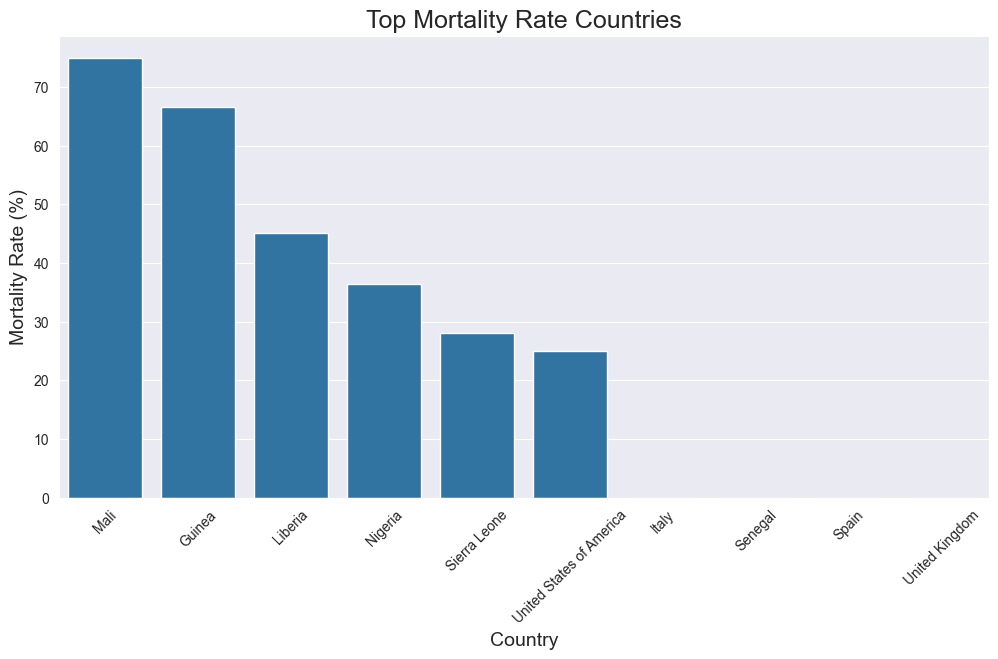

In [56]:
# ==============================
# MORTALITY RATE GRAPH
# ==============================

top_mortality = country_stats.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_mortality.index,
    y=top_mortality['Mortality_Rate']
)

plt.title("Top Mortality Rate Countries", fontsize=18)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Mortality Rate (%)", fontsize=14)

plt.xticks(rotation=45)

plt.show()

In [57]:
# ==============================
# EXPORT FUTURE PREDICTIONS
# ==============================

future_df.to_csv(
    "ebola_future_predictions.csv",
    index=False
)

print("Future Predictions Exported Successfully!")

Future Predictions Exported Successfully!


In [58]:
# ==============================
# SAVE TRAINED MODELS
# ==============================

import joblib

# Save Random Forest model
joblib.dump(
    rf_cases,
    'ebola_cases_model.pkl'
)

# Save Linear Regression model
joblib.dump(
    lr_deaths,
    'ebola_deaths_model.pkl'
)

print("Models Saved Successfully!")

Models Saved Successfully!


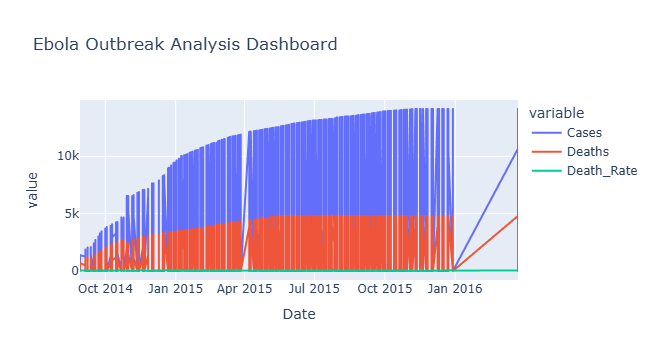

In [59]:
# ==============================
# FINAL PROFESSIONAL DASHBOARD
# ==============================

fig = px.line(
    df1,
    
    x='Date',
    
    y=[
        'Cases',
        'Deaths',
        'Death_Rate'
    ],
    
    title='Ebola Outbreak Analysis Dashboard'
)

fig.show()